
Iteration 19 results | k=4
Log Likelihood: 679465.153
Silhouette : 0.172

Cluster Profile (means, original scale) -- Iteration 19 (GaussianMixture + MinMaxScaler, tied):


cluster_size,daily_listening_minutes,sessions_per_day,days_active_last_30,avg_session_minutes,skip_rate,liked_songs_pct,ads_skipped_pct
30158,44.661470411745206,1.308,22.25635007757437,36.235631455318156,0.26,0.25958157873850785,0.7486567547826649
27477,32.860883831718276,1.221,15.273726870442516,27.548533624084094,0.261,0.24817014530482895,0.4787565722776589
22120,29.748006190824242,1.205,21.871743247833017,24.840686236405134,0.587,0.2632434561830335,0.5171431125296785
28245,57.89734360699958,1.473,25.203119616397952,40.88378448662752,0.254,0.3695793744653036,0.4092398555425233


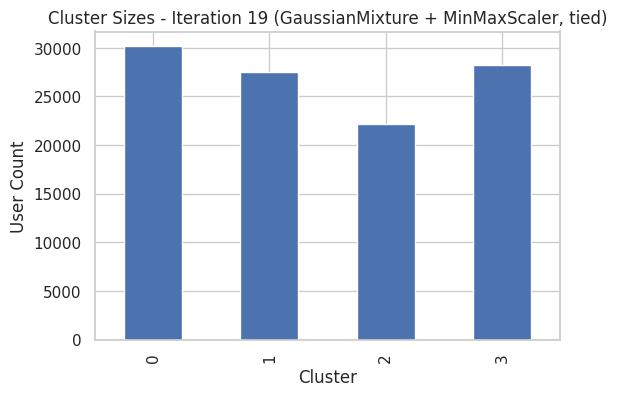

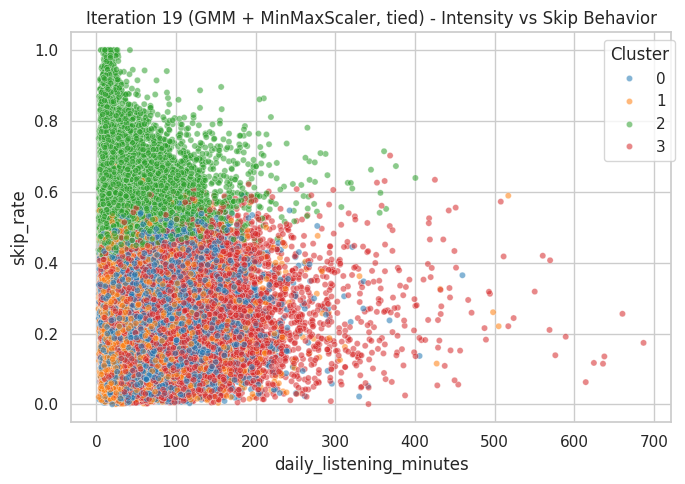

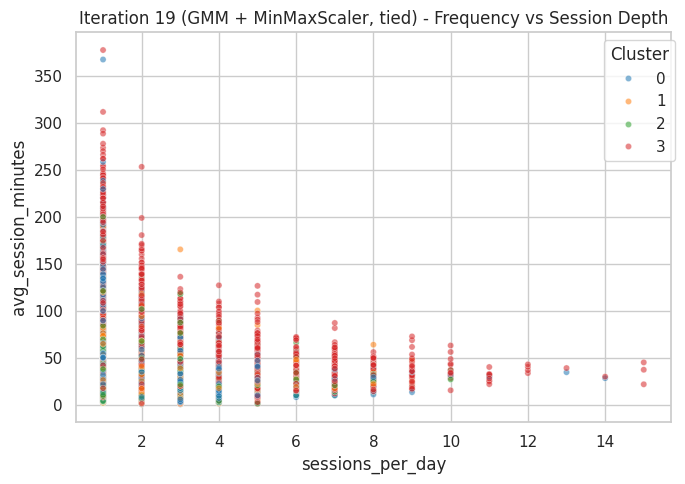

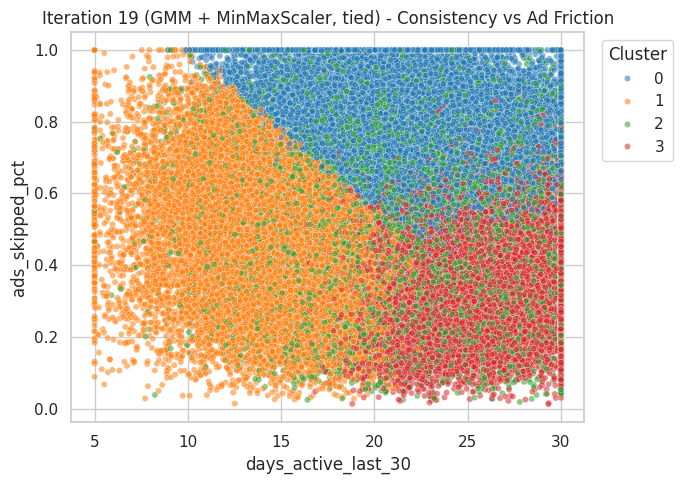

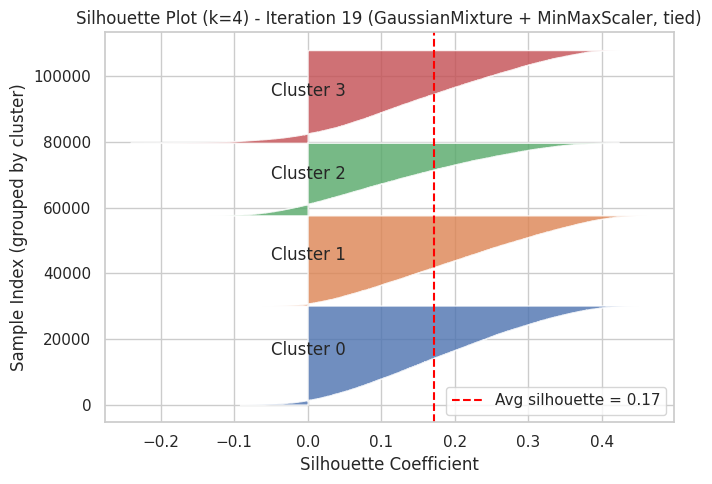

Iteration 19 Avg Silhouette: 0.172


In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score, silhouette_samples

# -----------------------------
# Load data
# -----------------------------
spotify_user_behavior = spark.table(
    "spotify.spotify_user_behavior"
).toPandas()

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

# -----------------------------
# Feature selection
# -----------------------------
CLUSTER_FEATURES_V1 = [
    "daily_listening_minutes",   # usage intensity
    "sessions_per_day",          # frequency
    "days_active_last_30",       # consistency
    "avg_session_minutes",       # depth
    "skip_rate",                 # content friction
    "liked_songs_pct",           # positive engagement
    "ads_skipped_pct"            # monetization friction
]

base = spotify_user_behavior[["user_id"] + CLUSTER_FEATURES_V1].copy()

# -----------------------------
# Parameters
# -----------------------------
K = 4

# -----------------------------
# MinMax Scaling
# -----------------------------
X19 = base[CLUSTER_FEATURES_V1].copy()

minmax = MinMaxScaler()
X19_scaled = minmax.fit_transform(X19)

X19 = pd.DataFrame(
    X19_scaled,
    columns=CLUSTER_FEATURES_V1,
    index=base.index
)

# -----------------------------
# Gaussian Mixture Model
# -----------------------------
gmm19 = GaussianMixture(
    n_components=K,
    covariance_type="tied",
    random_state=42,
    n_init=5,
    max_iter=200
)

labels19 = gmm19.fit_predict(X19)

log_likelihood19 = gmm19.score(X19) * len(X19)
sill_avg_19 = silhouette_score(X19, labels19)

# -----------------------------
# Attach clusters
# -----------------------------
base_iter19 = base.copy()
base_iter19["cluster"] = labels19

print(f"\nIteration 19 results | k={K}")
print("Log Likelihood:", round(log_likelihood19, 3))
print("Silhouette :", round(sill_avg_19, 3))

# -----------------------------
# Cluster profiles
# -----------------------------
sizes19 = base_iter19["cluster"].value_counts().sort_index()
means19 = (
    base_iter19
    .groupby("cluster")[CLUSTER_FEATURES_V1]
    .mean()
    .round(3)
)

profile19 = means19.copy()
profile19.insert(0, "cluster_size", sizes19)

print("\nCluster Profile (means, original scale) -- Iteration 19 (GaussianMixture + MinMaxScaler, tied):")
display(profile19)

# -----------------------------
# Cluster size plot
# -----------------------------
plt.figure(figsize=(6,4))
base_iter19["cluster"].value_counts().sort_index().plot(kind="bar")
plt.title("Cluster Sizes - Iteration 19 (GaussianMixture + MinMaxScaler, tied)")
plt.xlabel("Cluster")
plt.ylabel("User Count")
plt.show()

# -----------------------------
# Scatter plots
# -----------------------------
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=base_iter19,
    x="daily_listening_minutes",
    y="skip_rate",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55
)
plt.title("Iteration 19 (GMM + MinMaxScaler, tied) - Intensity vs Skip Behavior")
plt.legend(title="Cluster", bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=base_iter19,
    x="sessions_per_day",
    y="avg_session_minutes",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55
)
plt.title("Iteration 19 (GMM + MinMaxScaler, tied) - Frequency vs Session Depth")
plt.legend(title="Cluster", bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=base_iter19,
    x="days_active_last_30",
    y="ads_skipped_pct",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55
)
plt.title("Iteration 19 (GMM + MinMaxScaler, tied) - Consistency vs Ad Friction")
plt.legend(title="Cluster", bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.show()

# -----------------------------
# Silhouette Plot (MANUAL – no loop)
# -----------------------------
sil_value_19 = silhouette_samples(X19, labels19)

plt.figure(figsize=(7,5))
y_lower = 0

# Cluster 0
vals0 = sil_value_19[labels19 == 0]
vals0.sort()
size0 = vals0.shape[0]
y_upper = y_lower + size0
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals0, alpha=0.8)
plt.text(-0.05, y_lower + 0.5 * size0, "Cluster 0")
y_lower = y_upper

# Cluster 1
vals1 = sil_value_19[labels19 == 1]
vals1.sort()
size1 = vals1.shape[0]
y_upper = y_lower + size1
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals1, alpha=0.8)
plt.text(-0.05, y_lower + 0.5 * size1, "Cluster 1")
y_lower = y_upper

# Cluster 2
vals2 = sil_value_19[labels19 == 2]
vals2.sort()
size2 = vals2.shape[0]
y_upper = y_lower + size2
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals2, alpha=0.8)
plt.text(-0.05, y_lower + 0.5 * size2, "Cluster 2")
y_lower = y_upper

# Cluster 3
vals3 = sil_value_19[labels19 == 3]
vals3.sort()
size3 = vals3.shape[0]
y_upper = y_lower + size3
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals3, alpha=0.8)
plt.text(-0.05, y_lower + 0.5 * size3, "Cluster 3")
y_lower = y_upper

plt.axvline(
    x=sill_avg_19,
    color="red",
    linestyle="--",
    label=f"Avg silhouette = {sill_avg_19:.2f}"
)

plt.title("Silhouette Plot (k=4) - Iteration 19 (GaussianMixture + MinMaxScaler, tied)")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Sample Index (grouped by cluster)")
plt.legend()
plt.tight_layout()
plt.show()

print("Iteration 19 Avg Silhouette:", round(sill_avg_19, 3))
